In [6]:
import json
import re
from dataclasses import dataclass
from typing import Dict, Any, List, Optional

import pandas as pd
import matplotlib.pyplot as plt
from openai import OpenAI



client = OpenAI(
    api_key="ollama",
    base_url="http://localhost:11434/v1"
)

MODEL_NAME = "mistral:7b"



def is_bool_series(s: pd.Series) -> bool:
    if pd.api.types.is_bool_dtype(s):
        return True
    if s.dtype == "object":
        vals = set(s.dropna().unique().tolist())
        return vals.issubset({True, False, "True", "False", "true", "false", 0, 1, "0", "1"})
    return False


def coerce_bool_value(v: Any) -> Optional[bool]:
    if v is None:
        return None
    if isinstance(v, bool):
        return v
    if isinstance(v, (int, float)) and v in (0, 1):
        return bool(int(v))
    if isinstance(v, str):
        t = v.strip().lower()
        if t in ("true", "vrai", "1", "yes", "y"):
            return True
        if t in ("false", "faux", "0", "no", "n"):
            return False
    return None


def safe_apply_filters(df: pd.DataFrame, filters: List[Dict[str, Any]]) -> pd.DataFrame:
    if not filters:
        return df

    out = df.copy()

    for f in filters:
        if not isinstance(f, dict):
            print(f"[filter] ignore: filtre invalide {f}")
            continue

        col = f.get("column")
        val = f.get("value")
        op = f.get("op", "==")

        if isinstance(col, list):
            col = col[0] if col else None

        if col not in out.columns:
            print(f"[filter] ignore: colonne inconnue {col}")
            continue

        s = out[col]

        # Bool robuste
        if is_bool_series(s):
            b = coerce_bool_value(val)
            if b is None:
                b = True
            out = out[s.astype(str).str.lower().isin([str(b).lower()])]
            continue

        # Vérif valeur existante pour string si op equality
        if val is not None and op in ("==", None):
            if pd.api.types.is_object_dtype(s) or pd.api.types.is_string_dtype(s):
                uniques = set(s.dropna().astype(str).unique().tolist())
                if str(val) not in uniques:
                    print(f"[filter] ignore: la valeur '{val}' n'est pas dans {col}")
                    continue

        # Application
        if op == "==" or op is None:
            out = out[out[col] == val]
        elif op == "!=":
            out = out[out[col] != val]
        elif op in (">", ">=", "<", "<="):
            sn = pd.to_numeric(out[col], errors="coerce")
            vn = pd.to_numeric(pd.Series([val]), errors="coerce").iloc[0]
            if pd.isna(vn):
                print(f"[filter] ignore: valeur non numérique pour opé numérique: {val}")
                continue
            if op == ">":
                out = out[sn > vn]
            elif op == ">=":
                out = out[sn >= vn]
            elif op == "<":
                out = out[sn < vn]
            elif op == "<=":
                out = out[sn <= vn]
        elif op == "contains":
            out = out[out[col].astype(str).str.contains(str(val), na=False)]
        elif op == "in" and isinstance(val, list):
            out = out[out[col].isin(val)]
        else:
            print(f"[filter] ignore: opération non supportée {op}")
            continue

    return out



def flatten_json(obj, parent="", sep="_"):
    items = {}
    for k, v in obj.items():
        new_key = f"{parent}{sep}{k}" if parent else k
        if isinstance(v, dict):
            items.update(flatten_json(v, new_key, sep=sep))
        else:
            items[new_key] = v
    return items


def load_df(path: str, sample_rows: int = 5000):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if i >= sample_rows:
                break
            line = line.strip()
            if not line:
                continue
            obj = json.loads(line)
            rows.append(flatten_json(obj))

    df = pd.DataFrame(rows)
    df.columns = df.columns.str.strip()
    return df



INTENT_SYSTEM = """
You are a data visualization intent extractor.

Return ONLY valid JSON:

{
  "intent": "count" | "scatter" | "line" | "distribution" | "trend" | "time_series" | "histogram" | "table" | "metric",
  "chart": "auto" | "bar" | "scatter" | "line" | "area" | "pie" | "histogram" | "table" | "metric",
  "aggregation": "count" | "sum" | "mean" | "avg" | "min" | "max" | "nunique" | null,
  "group_by": string | [string] | null,
  "x": string | [string] | null,
  "y": string | [string] | null,
  "top_n": number | null,
  "bins": number | null,
  "filter": [{"column": string, "value": any, "op": "==" | "!=" | ">" | ">=" | "<" | "<=" | "contains" | "in"}] | []
}

Rules:
- Use ONLY column names provided in SCHEMA.
- If user asks for "nombre", "combien", "count", "répartition", use aggregation="count".
- If user asks for "moyenne", use aggregation="mean".
- If user asks for "somme"/"total", use aggregation="sum".
- If user asks for "minimum"/"maximum", use aggregation="min"/"max".
- If user asks "nombre de valeurs uniques", use aggregation="nunique".
- Prefer chart="line" for temporal evolution / trend.
- Prefer chart="histogram" for distribution of ONE numeric variable.
- Return JSON only.
"""


def extract_intent(prompt: str, df: pd.DataFrame) -> Dict[str, Any]:
    schema = list(df.columns)

    msg = f"""
SCHEMA:
{schema}

USER_PROMPT:
{prompt}
"""

    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[
            {"role": "system", "content": INTENT_SYSTEM},
            {"role": "user", "content": msg},
        ],
        temperature=0.1,
    )

    content = response.choices[0].message.content.strip()
    content = re.sub(r"^```(?:json)?", "", content).strip()
    content = re.sub(r"```$", "", content).strip()

    return json.loads(content)



# HELPERS NORMALISATION / AGGREGATION

def _first_if_list(v):
    if isinstance(v, list):
        return v[0] if v else None
    return v


def _safe_int(v, default=None):
    try:
        return int(v) if v is not None else default
    except Exception:
        return default


def normalize_agg_name(agg: Optional[str]) -> Optional[str]:
    if agg is None:
        return None
    agg = str(agg).lower().strip()
    if agg == "avg":
        return "mean"
    return agg


def maybe_to_datetime_series(s: pd.Series) -> pd.Series:
    # Ne convertir en datetime que si c'est du texte (timestamps)
    if pd.api.types.is_numeric_dtype(s):
        return s
    try:
        s_dt = pd.to_datetime(s, errors="coerce")
        if len(s) > 0 and s_dt.notna().sum() >= max(1, int(0.5 * len(s))):
            return s_dt
    except Exception:
        pass
    return s


def aggregate_series(s: pd.Series, agg: str) -> Any:
    agg = normalize_agg_name(agg)
    if agg == "count":
        return int(s.shape[0])
    if agg == "sum":
        return pd.to_numeric(s, errors="coerce").sum()
    if agg == "mean":
        return pd.to_numeric(s, errors="coerce").mean()
    if agg == "min":
        return pd.to_numeric(s, errors="coerce").min()
    if agg == "max":
        return pd.to_numeric(s, errors="coerce").max()
    if agg == "nunique":
        return int(s.nunique(dropna=True))
    raise ValueError(f"Agrégation non supportée: {agg}")


def groupby_aggregate(df: pd.DataFrame, group_by: str, y: Optional[str], agg: str) -> pd.DataFrame:
    agg = normalize_agg_name(agg) or "count"

    if group_by not in df.columns:
        raise ValueError(f"group_by inconnu: {group_by}")

    if agg == "count":
        out = df[group_by].value_counts(dropna=False).reset_index()
        out.columns = [group_by, "value"]
        return out

    if y is None or y not in df.columns:
        raise ValueError(f"Aggregation '{agg}' nécessite une colonne y valide.")

    if agg in ("sum", "mean", "min", "max"):
        tmp = df[[group_by, y]].copy()
        tmp[y] = pd.to_numeric(tmp[y], errors="coerce")
        tmp = tmp.dropna(subset=[y])
        if tmp.empty:
            return pd.DataFrame(columns=[group_by, "value"])
        grouped = tmp.groupby(group_by, dropna=False)[y].agg(agg).reset_index()
        grouped.columns = [group_by, "value"]
        return grouped

    if agg == "nunique":
        tmp = df[[group_by, y]].copy()
        grouped = tmp.groupby(group_by, dropna=False)[y].nunique(dropna=True).reset_index()
        grouped.columns = [group_by, "value"]
        return grouped

    raise ValueError(f"agg non supportée: {agg}")



# fait toutes les normalisations nécessaires pour que l'intent soit dans une forme stable et facilement réparable (ex: group_by peut être list ou str, on garde que le premier élément)
def normalize_intent(intent: Dict[str, Any]) -> Dict[str, Any]:
    out = dict(intent) if isinstance(intent, dict) else {}

    out["chart"] = (out.get("chart") or "auto")
    if isinstance(out["chart"], str):
        out["chart"] = out["chart"].lower()

    if isinstance(out.get("intent"), str):
        out["intent"] = out["intent"].lower()

    out["aggregation"] = normalize_agg_name(out.get("aggregation"))

    out["group_by"] = _first_if_list(out.get("group_by"))
    out["x"] = _first_if_list(out.get("x"))
    out["y"] = _first_if_list(out.get("y"))

    out["top_n"] = _safe_int(out.get("top_n"), None)
    out["bins"] = _safe_int(out.get("bins"), None)

    filters = out.get("filter")
    if not isinstance(filters, list):
        filters = []
    cleaned_filters = []
    for f in filters:
        if not isinstance(f, dict):
            continue
        cleaned_filters.append({
            "column": _first_if_list(f.get("column")),
            "value": f.get("value"),
            "op": f.get("op", "=="),
        })
    out["filter"] = cleaned_filters

    return out


def repair_intent_for_engine(intent_n: Dict[str, Any], df: pd.DataFrame, prompt: str = "") -> Dict[str, Any]:
    out = dict(intent_n)
    prompt_l = (prompt or "").lower()

    # Colonnes invalides -> None
    for key in ("group_by", "x", "y"):
        val = out.get(key)
        if val is not None and val not in df.columns:
            print(f"[intent-repair] {key}='{val}' absent du schema -> None")
            out[key] = None

    group_by = out.get("group_by")
    y = out.get("y")
    agg = out.get("aggregation")

    # agg non exploitable sans y => count
    if group_by and agg in ("nunique", "sum", "mean", "min", "max") and not y:
        print(f"[intent-repair] agg='{agg}' sans y avec group_by -> count")
        out["aggregation"] = "count"

    # count par défaut pour distribution/count
    if out.get("intent") in ("distribution", "count") and out.get("aggregation") is None:
        out["aggregation"] = "count"

    # Répartition legacy => bar par défaut (sauf demande explicite table)
    asks_table = any(k in prompt_l for k in ["table", "tableau", "tabulaire"])
    if group_by and (out.get("intent") in ("distribution", "count") or "répartition" in prompt_l or "distribution" in prompt_l):
        if out.get("chart") in (None, "", "auto", "table") and not asks_table:
            print("[intent-repair] répartition legacy -> chart='bar'")
            out["chart"] = "bar"

    # chart histogram sans x/y => auto
    if out.get("chart") == "histogram" and not (out.get("x") or out.get("y")):
        out["chart"] = "auto"

    return out


def extract_intent_safe(prompt: str, df: pd.DataFrame) -> Dict[str, Any]:
    raw = extract_intent(prompt, df)
    norm = normalize_intent(raw)
    repaired = repair_intent_for_engine(norm, df, prompt)
    return repaired


# canonical intent: format stable et facilement exploitable pour mapping direct vers PlotSpec, avec toute la logique de fallback / réparation centralisée ici.
@dataclass
class CanonicalIntent:
    kind: str  # COUNT_ROWS, COUNT_BY_GROUP, AGG_BY_GROUP, SCATTER_XY, LINE_XY, HISTOGRAM_X, TABLE_BY_GROUP, METRIC_AGG
    filters: List[Dict[str, Any]]

    group_by: Optional[str] = None
    x: Optional[str] = None
    y: Optional[str] = None
    aggregation: Optional[str] = None

    chart_hint: Optional[str] = None
    top_n: Optional[int] = None
    bins: Optional[int] = None


def canonicalize_intent(intent: Dict[str, Any], df: pd.DataFrame, prompt: str = "") -> CanonicalIntent:
    """
    Convertit l'intent LLM en intention canonique stable.
    Toute la logique de fallback est ici (pas patchée partout).
    """
    i = normalize_intent(intent)
    prompt_l = (prompt or "").lower()

    chart = i.get("chart") or "auto"
    intent_type = i.get("intent")
    agg = normalize_agg_name(i.get("aggregation"))
    group_by = i.get("group_by")
    x = i.get("x")
    y = i.get("y")
    filters = i.get("filter") or []
    top_n = i.get("top_n")
    bins = i.get("bins")

    # Colonnes invalides => None
    for field_name, val in (("group_by", group_by), ("x", x), ("y", y)):
        if val is not None and val not in df.columns:
            print(f"[canonicalize] {field_name}='{val}' absent du schema -> None")
            if field_name == "group_by":
                group_by = None
            elif field_name == "x":
                x = None
            elif field_name == "y":
                y = None

    # agg par défaut si distribution/count
    if agg is None and intent_type in ("count", "distribution"):
        agg = "count"

    chart_is_explicit = chart not in (None, "", "auto")


    # 1) chart explicite prioritaire (règle clé)

    if chart_is_explicit:
        # SCATTER
        if chart == "scatter":
            if x and y:
                return CanonicalIntent("SCATTER_XY", filters=filters, x=x, y=y, chart_hint="scatter")
            # fallback stable
            if group_by:
                return CanonicalIntent("COUNT_BY_GROUP", filters=filters, group_by=group_by, aggregation="count", chart_hint="bar")
            return CanonicalIntent("COUNT_ROWS", filters=filters, aggregation="count", chart_hint="metric")

        # LINE
        if chart == "line":
            if x and y:
                return CanonicalIntent("LINE_XY", filters=filters, x=x, y=y, chart_hint="line")
            if group_by:
                # line agrégé si y+agg, sinon count by group
                if agg in ("sum", "mean", "min", "max", "nunique") and y:
                    return CanonicalIntent("AGG_BY_GROUP", filters=filters, group_by=group_by, y=y, aggregation=agg, chart_hint="line", top_n=top_n)
                return CanonicalIntent("COUNT_BY_GROUP", filters=filters, group_by=group_by, aggregation="count", chart_hint="line", top_n=top_n)
            return CanonicalIntent("COUNT_ROWS", filters=filters, aggregation="count", chart_hint="metric")

        # BAR / PIE / AREA explicites (sur group_by)
        if chart in ("bar", "pie", "area"):
            if group_by:
                # agg by group valide seulement si y présent pour agg non-count
                if agg in ("sum", "mean", "min", "max", "nunique"):
                    if y:
                        return CanonicalIntent("AGG_BY_GROUP", filters=filters, group_by=group_by, y=y, aggregation=agg, chart_hint=chart, top_n=top_n)
                    # fallback propre
                    print(f"[canonicalize] {chart}+{agg} sans y -> COUNT_BY_GROUP")
                    return CanonicalIntent("COUNT_BY_GROUP", filters=filters, group_by=group_by, aggregation="count", chart_hint=chart, top_n=top_n)
                return CanonicalIntent("COUNT_BY_GROUP", filters=filters, group_by=group_by, aggregation="count", chart_hint=chart, top_n=top_n)

            # area XY explicite si x,y
            if chart == "area" and x and y:
                return CanonicalIntent("LINE_XY", filters=filters, x=x, y=y, chart_hint="area")

            # fallback
            return CanonicalIntent("COUNT_ROWS", filters=filters, aggregation="count", chart_hint="metric")

        # HISTOGRAM
        if chart == "histogram":
            col = x or y
            if col:
                return CanonicalIntent("HISTOGRAM_X", filters=filters, x=col, bins=bins or 20, chart_hint="histogram")
            return CanonicalIntent("COUNT_ROWS", filters=filters, aggregation="count", chart_hint="metric")

        # TABLE
        if chart == "table":
            if group_by:
                if agg in ("sum", "mean", "min", "max", "nunique") and y:
                    return CanonicalIntent("AGG_BY_GROUP", filters=filters, group_by=group_by, y=y, aggregation=agg, chart_hint="table", top_n=top_n)
                return CanonicalIntent("TABLE_BY_GROUP", filters=filters, group_by=group_by, aggregation="count", chart_hint="table", top_n=top_n)
            if x and y:
                # table simple xy -> table by x fallback non groupé non géré; on affichera table brute plus bas via TABLE_BY_GROUP fallback impossible.
                return CanonicalIntent("TABLE_BY_GROUP", filters=filters, group_by=x, aggregation="count", chart_hint="table", top_n=top_n)
            if x:
                return CanonicalIntent("TABLE_BY_GROUP", filters=filters, group_by=x, aggregation="count", chart_hint="table", top_n=top_n)
            return CanonicalIntent("COUNT_ROWS", filters=filters, aggregation="count", chart_hint="metric")

        # METRIC
        if chart == "metric":
            if agg in ("sum", "mean", "min", "max", "nunique") and y:
                return CanonicalIntent("METRIC_AGG", filters=filters, y=y, aggregation=agg, chart_hint="metric")
            return CanonicalIntent("COUNT_ROWS", filters=filters, aggregation="count", chart_hint="metric")

   
    # 2) Déduction par intent (si chart absent/auto)
    if intent_type in ("scatter",) and x and y:
        return CanonicalIntent("SCATTER_XY", filters=filters, x=x, y=y, chart_hint="scatter")

    if intent_type in ("line", "trend", "time_series") and x and y:
        return CanonicalIntent("LINE_XY", filters=filters, x=x, y=y, chart_hint="line")

    if intent_type in ("histogram",):
        col = x or y
        if col:
            return CanonicalIntent("HISTOGRAM_X", filters=filters, x=col, bins=bins or 20, chart_hint="histogram")

    if intent_type in ("table",):
        if group_by:
            if agg in ("sum", "mean", "min", "max", "nunique") and y:
                return CanonicalIntent("AGG_BY_GROUP", filters=filters, group_by=group_by, y=y, aggregation=agg, chart_hint="table", top_n=top_n)
            return CanonicalIntent("TABLE_BY_GROUP", filters=filters, group_by=group_by, aggregation="count", chart_hint="table", top_n=top_n)

    if intent_type in ("metric",):
        if agg in ("sum", "mean", "min", "max", "nunique") and y:
            return CanonicalIntent("METRIC_AGG", filters=filters, y=y, aggregation=agg, chart_hint="metric")
        return CanonicalIntent("COUNT_ROWS", filters=filters, aggregation="count", chart_hint="metric")

    # -------------------------------------------------
    # 3) Heuristiques métier (legacy-friendly)
    # -------------------------------------------------
    # Répartition / count par groupe (comportement historique)
    if group_by and (intent_type in ("distribution", "count") or "répartition" in prompt_l or "distribution" in prompt_l):
        # agg by group si vraiment valide
        if agg in ("sum", "mean", "min", "max", "nunique") and y:
            return CanonicalIntent("AGG_BY_GROUP", filters=filters, group_by=group_by, y=y, aggregation=agg, chart_hint="bar", top_n=top_n)
        return CanonicalIntent("COUNT_BY_GROUP", filters=filters, group_by=group_by, aggregation="count", chart_hint="bar", top_n=top_n)

    # agg sans group_by => metric
    if agg in ("sum", "mean", "min", "max", "nunique") and y:
        return CanonicalIntent("METRIC_AGG", filters=filters, y=y, aggregation=agg, chart_hint="metric")

    # x+y => line ou scatter selon intent
    if x and y:
        if intent_type in ("trend", "time_series", "line"):
            return CanonicalIntent("LINE_XY", filters=filters, x=x, y=y, chart_hint="line")
        return CanonicalIntent("SCATTER_XY", filters=filters, x=x, y=y, chart_hint="scatter")

    # group_by seul => count by group
    if group_by:
        return CanonicalIntent("COUNT_BY_GROUP", filters=filters, group_by=group_by, aggregation="count", chart_hint="bar", top_n=top_n)

    # fallback ultime
    return CanonicalIntent("COUNT_ROWS", filters=filters, aggregation="count", chart_hint="metric")


# PLOTSPEC + BUILD FROM CANONICAL (DETERMINISTE)
@dataclass
class PlotSpec:
    plot_type: str  # bar_agg, single_count, scatter, line, area_xy, pie, histogram, metric, table, line_agg, area_agg
    x: Optional[str] = None
    y: Optional[str] = None
    group_by: Optional[str] = None
    filters: Optional[List[Dict[str, Any]]] = None
    sort_by: Optional[str] = None  # x, y, value
    sort_ascending: bool = False
    aggregation: Optional[str] = None
    top_n: Optional[int] = None
    bins: Optional[int] = None


def build_plot_spec_from_canonical(ci: CanonicalIntent) -> PlotSpec:
    """
    Ici on ne 'répare' plus l'intent. On mappe juste CanonicalIntent -> PlotSpec.
    """
    if ci.kind == "COUNT_ROWS":
        return PlotSpec(
            plot_type="single_count" if ci.chart_hint != "metric" else "metric",
            filters=ci.filters,
            aggregation="count",
        )

    if ci.kind == "COUNT_BY_GROUP":
        chart = ci.chart_hint or "bar"
        if chart == "table":
            return PlotSpec(
                plot_type="table",
                group_by=ci.group_by,
                filters=ci.filters,
                aggregation="count",
                top_n=ci.top_n,
                sort_by="value",
                sort_ascending=False,
            )
        if chart == "pie":
            return PlotSpec(
                plot_type="pie",
                group_by=ci.group_by,
                filters=ci.filters,
                aggregation="count",
                top_n=ci.top_n,
                sort_by="value",
                sort_ascending=False,
            )
        if chart == "line":
            return PlotSpec(
                plot_type="line_agg",
                group_by=ci.group_by,
                filters=ci.filters,
                aggregation="count",
                top_n=ci.top_n,
                sort_by="x",
                sort_ascending=True,
            )
        if chart == "area":
            return PlotSpec(
                plot_type="area_agg",
                group_by=ci.group_by,
                filters=ci.filters,
                aggregation="count",
                top_n=ci.top_n,
                sort_by="value",
                sort_ascending=False,
            )
        # défaut historique
        return PlotSpec(
            plot_type="bar_agg",
            group_by=ci.group_by,
            filters=ci.filters,
            aggregation="count",
            top_n=ci.top_n,
            sort_by="value",
            sort_ascending=False,
        )

    if ci.kind == "AGG_BY_GROUP":
        chart = ci.chart_hint or "bar"
        if chart == "table":
            return PlotSpec(
                plot_type="table",
                group_by=ci.group_by,
                y=ci.y,
                filters=ci.filters,
                aggregation=ci.aggregation,
                top_n=ci.top_n,
                sort_by="value",
                sort_ascending=False,
            )
        if chart == "pie":
            return PlotSpec(
                plot_type="pie",
                group_by=ci.group_by,
                y=ci.y,
                filters=ci.filters,
                aggregation=ci.aggregation,
                top_n=ci.top_n,
                sort_by="value",
                sort_ascending=False,
            )
        if chart == "line":
            return PlotSpec(
                plot_type="line_agg",
                group_by=ci.group_by,
                y=ci.y,
                filters=ci.filters,
                aggregation=ci.aggregation,
                top_n=ci.top_n,
                sort_by="x",
                sort_ascending=True,
            )
        if chart == "area":
            return PlotSpec(
                plot_type="area_agg",
                group_by=ci.group_by,
                y=ci.y,
                filters=ci.filters,
                aggregation=ci.aggregation,
                top_n=ci.top_n,
                sort_by="value",
                sort_ascending=False,
            )
        return PlotSpec(
            plot_type="bar_agg",
            group_by=ci.group_by,
            y=ci.y,
            filters=ci.filters,
            aggregation=ci.aggregation,
            top_n=ci.top_n,
            sort_by="value",
            sort_ascending=False,
        )

    if ci.kind == "SCATTER_XY":
        return PlotSpec(
            plot_type="scatter",
            x=ci.x,
            y=ci.y,
            filters=ci.filters,
        )

    if ci.kind == "LINE_XY":
        if ci.chart_hint == "area":
            return PlotSpec(
                plot_type="area_xy",
                x=ci.x,
                y=ci.y,
                filters=ci.filters,
                sort_by="x",
                sort_ascending=True,
            )
        return PlotSpec(
            plot_type="line",
            x=ci.x,
            y=ci.y,
            filters=ci.filters,
            sort_by="x",
            sort_ascending=True,
        )

    if ci.kind == "HISTOGRAM_X":
        return PlotSpec(
            plot_type="histogram",
            x=ci.x,
            filters=ci.filters,
            bins=ci.bins or 20,
            sort_by="x",
            sort_ascending=True,
        )

    if ci.kind == "TABLE_BY_GROUP":
        return PlotSpec(
            plot_type="table",
            group_by=ci.group_by,
            filters=ci.filters,
            aggregation=ci.aggregation or "count",
            top_n=ci.top_n,
            sort_by="value",
            sort_ascending=False,
        )

    if ci.kind == "METRIC_AGG":
        return PlotSpec(
            plot_type="metric",
            y=ci.y,
            filters=ci.filters,
            aggregation=ci.aggregation,
        )

    # fallback
    return PlotSpec(plot_type="single_count", filters=ci.filters, aggregation="count")


# PREPARE PLOT DATA (DETERMINISTE)
def prepare_plot_data(df: pd.DataFrame, spec: PlotSpec, prompt: str = "") -> Dict[str, Any]:
    df_f = safe_apply_filters(df, spec.filters or [])

    if df_f.empty:
        print("[warn] filtres -> df vide, fallback sur df original")
        df_f = df.copy()

    # -------- BAR AGG
    if spec.plot_type == "bar_agg":
        gb = spec.group_by
        agg = spec.aggregation or "count"

        try:
            plot_df = groupby_aggregate(df_f, gb, spec.y, agg)
        except Exception as e:
            print(f"[prepare] bar_agg fallback count ({e})")
            plot_df = groupby_aggregate(df_f, gb, None, "count")
            agg = "count"

        if spec.top_n is not None and spec.top_n > 0:
            plot_df = plot_df.head(spec.top_n)

        ylabel = "Count" if agg == "count" else f"{agg}({spec.y})"
        return {
            "plot_type": "bar_agg",
            "data": plot_df,
            "x": gb,
            "y": "value",
            "title": prompt,
            "xlabel": gb,
            "ylabel": ylabel,
        }

    # -------- PIE
    if spec.plot_type == "pie":
        gb = spec.group_by
        agg = spec.aggregation or "count"

        try:
            plot_df = groupby_aggregate(df_f, gb, spec.y, agg)
        except Exception as e:
            print(f"[prepare] pie fallback count ({e})")
            plot_df = groupby_aggregate(df_f, gb, None, "count")

        if spec.top_n is not None and spec.top_n > 0:
            plot_df = plot_df.head(spec.top_n)

        if plot_df.empty:
            plot_df = pd.DataFrame({gb: ["No data"], "value": [0]})

        return {
            "plot_type": "pie",
            "data": plot_df,
            "x": gb,
            "y": "value",
            "title": prompt,
            "xlabel": gb,
            "ylabel": "Value",
        }

    # -------- TABLE
    if spec.plot_type == "table":
        if spec.group_by:
            agg = spec.aggregation or "count"
            try:
                plot_df = groupby_aggregate(df_f, spec.group_by, spec.y, agg)
            except Exception as e:
                print(f"[prepare] table fallback count ({e})")
                plot_df = groupby_aggregate(df_f, spec.group_by, None, "count")

            if spec.top_n is not None and spec.top_n > 0:
                plot_df = plot_df.head(spec.top_n)

            return {
                "plot_type": "table",
                "data": plot_df,
                "title": prompt,
            }

        cols = [c for c in [spec.x, spec.y] if c and c in df_f.columns]
        if not cols:
            cols = list(df_f.columns[:5])

        return {
            "plot_type": "table",
            "data": df_f[cols].copy().head(spec.top_n or 20),
            "title": prompt,
        }

    # -------- METRIC / SINGLE COUNT
    if spec.plot_type in ("metric", "single_count"):
        agg = spec.aggregation or "count"

        if spec.plot_type == "single_count" or (agg == "count" and not spec.y):
            val = len(df_f)
            label = "Count"
        else:
            if spec.y and spec.y in df_f.columns:
                try:
                    val = aggregate_series(df_f[spec.y], agg)
                    label = f"{agg}({spec.y})"
                except Exception as e:
                    print(f"[prepare] metric fallback count ({e})")
                    val = len(df_f)
                    label = "Count"
            else:
                val = len(df_f)
                label = "Count"

        return {
            "plot_type": "metric" if spec.plot_type == "metric" else "single_count",
            "data": pd.DataFrame({"label": [label], "value": [val]}),
            "x": "label",
            "y": "value",
            "title": prompt,
            "xlabel": None,
            "ylabel": None if spec.plot_type == "metric" else "Number of entities",
        }

    # -------- HISTOGRAM
    if spec.plot_type == "histogram":
        col = spec.x
        if col not in df_f.columns:
            print("[prepare] histogram colonne invalide -> single_count")
            return {
                "plot_type": "single_count",
                "data": pd.DataFrame({"label": ["Count"], "value": [len(df_f)]}),
                "x": "label",
                "y": "value",
                "title": prompt,
                "xlabel": None,
                "ylabel": "Number of entities",
            }

        sn = pd.to_numeric(df_f[col], errors="coerce").dropna()
        if sn.empty:
            print("[prepare] histogram sans données num -> single_count")
            return {
                "plot_type": "single_count",
                "data": pd.DataFrame({"label": ["Count"], "value": [len(df_f)]}),
                "x": "label",
                "y": "value",
                "title": prompt,
                "xlabel": None,
                "ylabel": "Number of entities",
            }

        return {
            "plot_type": "histogram",
            "data": pd.DataFrame({col: sn}),
            "x": col,
            "bins": spec.bins or 20,
            "title": prompt,
            "xlabel": col,
            "ylabel": "Frequency",
        }

    # -------- SCATTER
    if spec.plot_type == "scatter":
        if spec.x not in df_f.columns or spec.y not in df_f.columns:
            print("[prepare] scatter colonnes invalides -> single_count")
            return {
                "plot_type": "single_count",
                "data": pd.DataFrame({"label": ["Count"], "value": [len(df_f)]}),
                "x": "label",
                "y": "value",
                "title": prompt,
                "xlabel": None,
                "ylabel": "Number of entities",
            }

        xs = pd.to_numeric(df_f[spec.x], errors="coerce")
        ys = pd.to_numeric(df_f[spec.y], errors="coerce")
        ok = xs.notna() & ys.notna()
        plot_df = pd.DataFrame({spec.x: xs[ok], spec.y: ys[ok]})

        if plot_df.empty:
            print("[prepare] scatter vide -> single_count")
            return {
                "plot_type": "single_count",
                "data": pd.DataFrame({"label": ["Count"], "value": [len(df_f)]}),
                "x": "label",
                "y": "value",
                "title": prompt,
                "xlabel": None,
                "ylabel": "Number of entities",
            }

        return {
            "plot_type": "scatter",
            "data": plot_df,
            "x": spec.x,
            "y": spec.y,
            "title": prompt,
            "xlabel": spec.x,
            "ylabel": spec.y,
        }

    # -------- LINE XY
    if spec.plot_type == "line":
        if spec.x not in df_f.columns or spec.y not in df_f.columns:
            print("[prepare] line colonnes invalides -> single_count")
            return {
                "plot_type": "single_count",
                "data": pd.DataFrame({"label": ["Count"], "value": [len(df_f)]}),
                "x": "label",
                "y": "value",
                "title": prompt,
                "xlabel": None,
                "ylabel": "Number of entities",
            }

        xs = df_f[spec.x]
        ys = pd.to_numeric(df_f[spec.y], errors="coerce")
        plot_df = pd.DataFrame({spec.x: xs, spec.y: ys}).dropna(subset=[spec.y])

        if plot_df.empty:
            print("[prepare] line vide -> single_count")
            return {
                "plot_type": "single_count",
                "data": pd.DataFrame({"label": ["Count"], "value": [len(df_f)]}),
                "x": "label",
                "y": "value",
                "title": prompt,
                "xlabel": None,
                "ylabel": "Number of entities",
            }

        plot_df[spec.x] = maybe_to_datetime_series(plot_df[spec.x])

        return {
            "plot_type": "line",
            "data": plot_df,
            "x": spec.x,
            "y": spec.y,
            "title": prompt,
            "xlabel": spec.x,
            "ylabel": spec.y,
        }

    # -------- AREA XY
    if spec.plot_type == "area_xy":
        if spec.x not in df_f.columns or spec.y not in df_f.columns:
            print("[prepare] area_xy colonnes invalides -> single_count")
            return {
                "plot_type": "single_count",
                "data": pd.DataFrame({"label": ["Count"], "value": [len(df_f)]}),
                "x": "label",
                "y": "value",
                "title": prompt,
                "xlabel": None,
                "ylabel": "Number of entities",
            }

        ys = pd.to_numeric(df_f[spec.y], errors="coerce")
        plot_df = pd.DataFrame({spec.x: df_f[spec.x], spec.y: ys}).dropna(subset=[spec.y])

        if plot_df.empty:
            print("[prepare] area_xy vide -> single_count")
            return {
                "plot_type": "single_count",
                "data": pd.DataFrame({"label": ["Count"], "value": [len(df_f)]}),
                "x": "label",
                "y": "value",
                "title": prompt,
                "xlabel": None,
                "ylabel": "Number of entities",
            }

        plot_df[spec.x] = maybe_to_datetime_series(plot_df[spec.x])

        return {
            "plot_type": "area_xy",
            "data": plot_df,
            "x": spec.x,
            "y": spec.y,
            "title": prompt,
            "xlabel": spec.x,
            "ylabel": spec.y,
        }

    # -------- LINE AGG / AREA AGG
    if spec.plot_type in ("line_agg", "area_agg"):
        try:
            plot_df = groupby_aggregate(df_f, spec.group_by, spec.y, spec.aggregation or "count")
        except Exception as e:
            print(f"[prepare] {spec.plot_type} fallback count ({e})")
            plot_df = groupby_aggregate(df_f, spec.group_by, None, "count")

        if spec.top_n is not None and spec.top_n > 0:
            plot_df = plot_df.head(spec.top_n)

        return {
            "plot_type": spec.plot_type,
            "data": plot_df,
            "x": spec.group_by,
            "y": "value",
            "title": prompt,
            "xlabel": spec.group_by,
            "ylabel": "Value",
        }

    raise ValueError(f"prepare_plot_data: plot_type non supporté {spec.plot_type}")


# SORT
def sort_plot_data(plot_data: Dict[str, Any], spec: PlotSpec) -> Dict[str, Any]:
    data = plot_data["data"].copy()

    if data.empty:
        plot_data["data"] = data
        return plot_data

    if spec.sort_by == "value" and "value" in data.columns:
        data = data.sort_values("value", ascending=spec.sort_ascending)
    elif spec.sort_by == "x" and plot_data.get("x") in data.columns:
        try:
            data = data.sort_values(plot_data["x"], ascending=spec.sort_ascending)
        except Exception:
            pass
    elif spec.sort_by == "y" and plot_data.get("y") in data.columns:
        try:
            data = data.sort_values(plot_data["y"], ascending=spec.sort_ascending)
        except Exception:
            pass

    plot_data["data"] = data
    return plot_data


# render_plot : fonction déterministe qui prend les données préparées et retourne un objet matplotlib prêt à être affiché.
def render_plot(plot_data: Dict[str, Any]):
    plot_type = plot_data["plot_type"]
    data = plot_data["data"]
    x = plot_data.get("x")
    y = plot_data.get("y")
    title = plot_data.get("title", "")
    xlabel = plot_data.get("xlabel")
    ylabel = plot_data.get("ylabel")

    fig, ax = plt.subplots()

    # BAR
    if plot_type == "bar_agg":
        if data.empty:
            ax.axis("off")
            ax.text(0.5, 0.5, "No data", ha="center", va="center")
        else:
            ax.bar(data[x].astype(str), data[y])
            ax.set_xlabel(xlabel or x)
            ax.set_ylabel(ylabel or y)
            ax.tick_params(axis="x", labelrotation=45)
        ax.set_title(title)
        plt.tight_layout()
        return plt

    # SINGLE COUNT
    if plot_type == "single_count":
        ax.bar(data[x].astype(str), data[y])
        if ylabel:
            ax.set_ylabel(ylabel)
        ax.set_title(title)
        plt.tight_layout()
        return plt

    # METRIC
    if plot_type == "metric":
        value = data.iloc[0][y] if (not data.empty and y in data.columns) else None
        label = data.iloc[0][x] if (not data.empty and x in data.columns) else "Metric"
        ax.axis("off")
        ax.text(0.5, 0.5, f"{label}\n{value}", ha="center", va="center", fontsize=16)
        ax.set_title(title)
        plt.tight_layout()
        return plt

    # TABLE
    if plot_type == "table":
        ax.axis("off")
        show_df = data.copy().head(20)
        if show_df.empty:
            show_df = pd.DataFrame({"info": ["No data"]})
        tbl = ax.table(
            cellText=show_df.astype(str).values,
            colLabels=show_df.columns.tolist(),
            loc="center"
        )
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(8)
        tbl.scale(1, 1.2)
        ax.set_title(title)
        plt.tight_layout()
        return plt

    # SCATTER
    if plot_type == "scatter":
        ax.scatter(data[x], data[y])
        ax.set_xlabel(xlabel or x)
        ax.set_ylabel(ylabel or y)
        ax.set_title(title)
        plt.tight_layout()
        return plt

    # LINE / LINE_AGG
    if plot_type in ("line", "line_agg"):
        if data.empty:
            ax.axis("off")
            ax.text(0.5, 0.5, "No data", ha="center", va="center")
        else:
            ax.plot(data[x], data[y], marker="o")
            ax.set_xlabel(xlabel or x)
            ax.set_ylabel(ylabel or y)
            ax.tick_params(axis="x", labelrotation=45)
        ax.set_title(title)
        plt.tight_layout()
        return plt

    # AREA_XY / AREA_AGG
    if plot_type in ("area_xy", "area_agg"):
        if data.empty:
            ax.axis("off")
            ax.text(0.5, 0.5, "No data", ha="center", va="center")
            ax.set_title(title)
            return plt

        y_num = pd.to_numeric(data[y], errors="coerce").fillna(0)
        idx = list(range(len(data)))
        ax.plot(idx, y_num.values, marker="o")
        ax.fill_between(idx, y_num.values, alpha=0.3)

        labels = data[x].astype(str).tolist()
        ax.set_xticks(idx)
        ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.set_xlabel(xlabel or x)
        ax.set_ylabel(ylabel or y)
        ax.set_title(title)
        plt.tight_layout()
        return plt

    # PIE
    if plot_type == "pie":
        pie_values = pd.to_numeric(data[y], errors="coerce").fillna(0)
        labels = data[x].astype(str)
        if pie_values.sum() <= 0:
            ax.axis("off")
            ax.text(0.5, 0.5, "No data for pie chart", ha="center", va="center")
        else:
            ax.pie(pie_values, labels=labels, autopct="%1.1f%%")
        ax.set_title(title)
        plt.tight_layout()
        return plt

    # HISTOGRAM
    if plot_type == "histogram":
        bins = plot_data.get("bins", 20)
        ax.hist(data[x], bins=bins)
        ax.set_xlabel(xlabel or x)
        ax.set_ylabel(ylabel or "Frequency")
        ax.set_title(title)
        plt.tight_layout()
        return plt

    raise ValueError(f"render_plot: plot_type non supporté {plot_type}")


# ORCHESTRATION

def plot_from_intent(df: pd.DataFrame, intent: Dict[str, Any], prompt: str):
    print("\nDEBUG INTENTION (safe/raw):", intent)

    ci = canonicalize_intent(intent, df, prompt=prompt)
    print("[debug] CanonicalIntent:", ci)

    spec = build_plot_spec_from_canonical(ci)
    print("[debug] PlotSpec:", spec)

    plot_data = prepare_plot_data(df, spec, prompt=prompt)
    plot_data = sort_plot_data(plot_data, spec)

    return render_plot(plot_data)


def run_llm_visualizer(file: str, prompt: str, out: str = "out.png"):
    df = load_df(file)

    intent = extract_intent_safe(prompt, df)
    print("\nINTENTION DETECTEE (safe):\n", intent)

    plt_obj = plot_from_intent(df, intent, prompt)

    plt_obj.savefig(out, bbox_inches="tight", dpi=300)
    plt_obj.show()
    plt_obj.close()

    print("\nGraph sauvegardé dans:", out)


[intent-repair] répartition legacy -> chart='bar'

INTENTION DETECTEE (safe):
 {'intent': 'distribution', 'chart': 'bar', 'aggregation': 'count', 'group_by': 'EntityIdentifier', 'filter': [{'column': 'DamageState', 'value': 'no damage', 'op': '=='}], 'x': None, 'y': None, 'top_n': None, 'bins': None}

DEBUG INTENTION (safe/raw): {'intent': 'distribution', 'chart': 'bar', 'aggregation': 'count', 'group_by': 'EntityIdentifier', 'filter': [{'column': 'DamageState', 'value': 'no damage', 'op': '=='}], 'x': None, 'y': None, 'top_n': None, 'bins': None}
[debug] CanonicalIntent: CanonicalIntent(kind='COUNT_BY_GROUP', filters=[{'column': 'DamageState', 'value': 'no damage', 'op': '=='}], group_by='EntityIdentifier', x=None, y=None, aggregation='count', chart_hint='bar', top_n=None, bins=None)
[debug] PlotSpec: PlotSpec(plot_type='bar_agg', x=None, y=None, group_by='EntityIdentifier', filters=[{'column': 'DamageState', 'value': 'no damage', 'op': '=='}], sort_by='value', sort_ascending=False, a

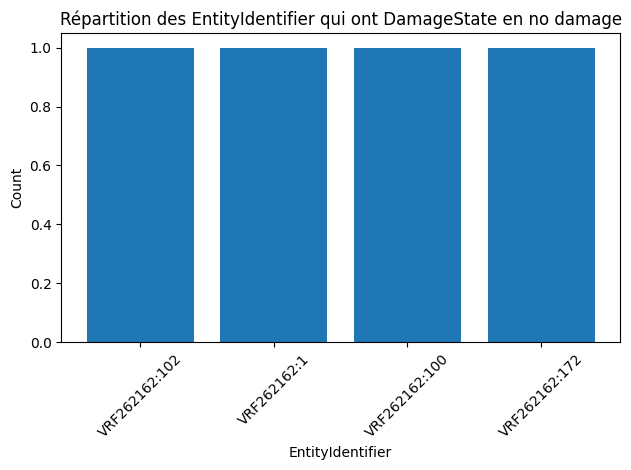


Graph sauvegardé dans: out78.png


In [4]:



run_llm_visualizer(
     file="data/lidata.log",
     prompt="Répartition des EntityIdentifier qui ont DamageState en no damage",
     out="out78.png"
 )



INTENTION DETECTEE (safe):
 {'intent': 'table', 'chart': 'bar', 'group_by': 'EntityIdentifier', 'x': 'HasAmmunitionSupplyCap', 'y': None, 'filter': [{'column': 'HasAmmunitionSupplyCap', 'value': False, 'op': '=='}], 'aggregation': None, 'top_n': None, 'bins': None}

DEBUG INTENTION (safe/raw): {'intent': 'table', 'chart': 'bar', 'group_by': 'EntityIdentifier', 'x': 'HasAmmunitionSupplyCap', 'y': None, 'filter': [{'column': 'HasAmmunitionSupplyCap', 'value': False, 'op': '=='}], 'aggregation': None, 'top_n': None, 'bins': None}
[debug] CanonicalIntent: CanonicalIntent(kind='COUNT_BY_GROUP', filters=[{'column': 'HasAmmunitionSupplyCap', 'value': False, 'op': '=='}], group_by='EntityIdentifier', x=None, y=None, aggregation='count', chart_hint='bar', top_n=None, bins=None)
[debug] PlotSpec: PlotSpec(plot_type='bar_agg', x=None, y=None, group_by='EntityIdentifier', filters=[{'column': 'HasAmmunitionSupplyCap', 'value': False, 'op': '=='}], sort_by='value', sort_ascending=False, aggregation

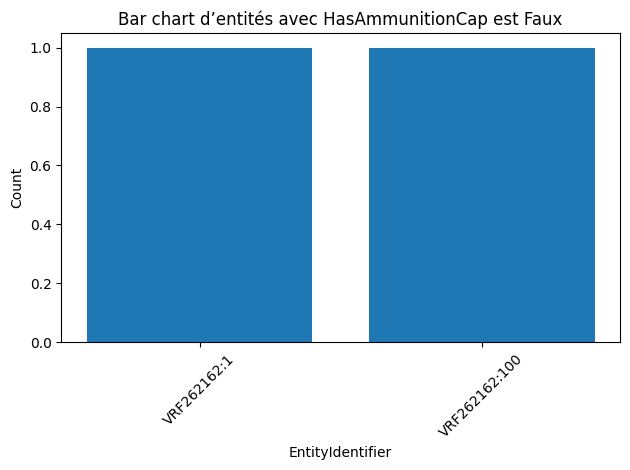


Graph sauvegardé dans: out.png


In [5]:

run_llm_visualizer(
     file="data/lidata.log",
     prompt="Bar chart d’entités avec HasAmmunitionCap est Faux",
     out="out.png"
 )


[intent-repair] agg='nunique' sans y avec group_by -> count

INTENTION DETECTEE (safe):
 {'intent': 'distribution', 'chart': 'pie', 'aggregation': 'count', 'group_by': 'ForceIdentifier', 'x': None, 'y': None, 'top_n': None, 'bins': None, 'filter': []}

DEBUG INTENTION (safe/raw): {'intent': 'distribution', 'chart': 'pie', 'aggregation': 'count', 'group_by': 'ForceIdentifier', 'x': None, 'y': None, 'top_n': None, 'bins': None, 'filter': []}
[debug] CanonicalIntent: CanonicalIntent(kind='COUNT_BY_GROUP', filters=[], group_by='ForceIdentifier', x=None, y=None, aggregation='count', chart_hint='pie', top_n=None, bins=None)
[debug] PlotSpec: PlotSpec(plot_type='pie', x=None, y=None, group_by='ForceIdentifier', filters=[], sort_by='value', sort_ascending=False, aggregation='count', top_n=None, bins=None)


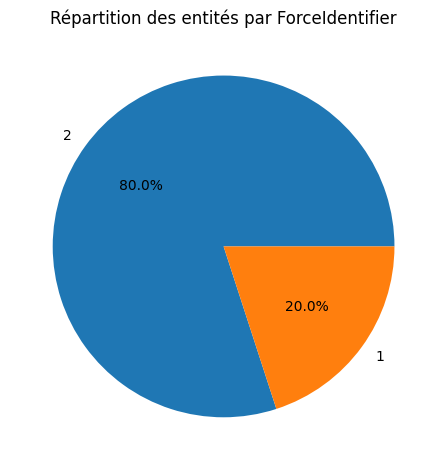


Graph sauvegardé dans: out_force.png


In [6]:

run_llm_visualizer(
    file="data/lidata.log",
     prompt="Répartition des entités par ForceIdentifier",
     out="out_force.png"
 )



INTENTION DETECTEE (safe):
 {'intent': 'scatter', 'chart': 'scatter', 'x': 'Spatial_FPB_WorldLocation_x', 'y': 'Spatial_FPB_WorldLocation_y', 'aggregation': None, 'group_by': None, 'top_n': None, 'bins': None, 'filter': []}

DEBUG INTENTION (safe/raw): {'intent': 'scatter', 'chart': 'scatter', 'x': 'Spatial_FPB_WorldLocation_x', 'y': 'Spatial_FPB_WorldLocation_y', 'aggregation': None, 'group_by': None, 'top_n': None, 'bins': None, 'filter': []}
[debug] CanonicalIntent: CanonicalIntent(kind='SCATTER_XY', filters=[], group_by=None, x='Spatial_FPB_WorldLocation_x', y='Spatial_FPB_WorldLocation_y', aggregation=None, chart_hint='scatter', top_n=None, bins=None)
[debug] PlotSpec: PlotSpec(plot_type='scatter', x='Spatial_FPB_WorldLocation_x', y='Spatial_FPB_WorldLocation_y', group_by=None, filters=[], sort_by=None, sort_ascending=False, aggregation=None, top_n=None, bins=None)


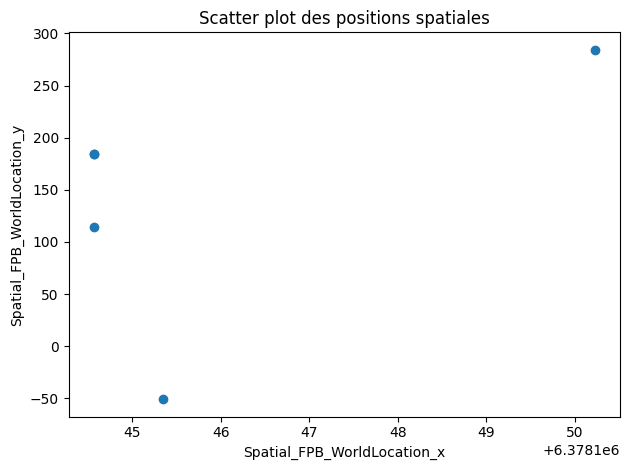


Graph sauvegardé dans: scatter.png


In [7]:

run_llm_visualizer(
     file="data/lidata.log",
     prompt="Scatter plot des positions spatiales",
     out="scatter.png"
 )



INTENTION DETECTEE (safe):
 {'intent': 'time_series', 'chart': 'line', 'aggregation': None, 'group_by': 'EntityType', 'x': 'SimTime', 'y': 'Spatial_FPB_WorldLocation_y', 'filter': [], 'top_n': None, 'bins': None}

DEBUG INTENTION (safe/raw): {'intent': 'time_series', 'chart': 'line', 'aggregation': None, 'group_by': 'EntityType', 'x': 'SimTime', 'y': 'Spatial_FPB_WorldLocation_y', 'filter': [], 'top_n': None, 'bins': None}
[debug] CanonicalIntent: CanonicalIntent(kind='LINE_XY', filters=[], group_by=None, x='SimTime', y='Spatial_FPB_WorldLocation_y', aggregation=None, chart_hint='line', top_n=None, bins=None)
[debug] PlotSpec: PlotSpec(plot_type='line', x='SimTime', y='Spatial_FPB_WorldLocation_y', group_by=None, filters=[], sort_by='x', sort_ascending=True, aggregation=None, top_n=None, bins=None)


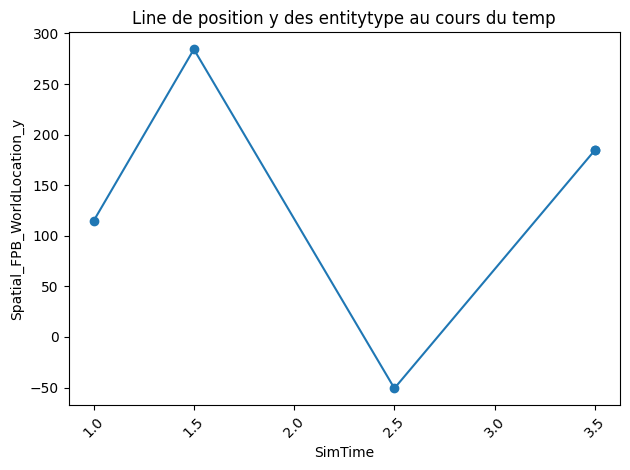


Graph sauvegardé dans: line.png


In [8]:

run_llm_visualizer(
     file="data/lidata.log",
     prompt="Line de position y des entitytype au cours du temp",
     out="line.png"
 )



INTENTION DETECTEE (safe):
 {'intent': 'histogram', 'chart': 'histogram', 'aggregation': None, 'group_by': None, 'x': 'SimTime', 'y': None, 'top_n': None, 'bins': None, 'filter': []}

DEBUG INTENTION (safe/raw): {'intent': 'histogram', 'chart': 'histogram', 'aggregation': None, 'group_by': None, 'x': 'SimTime', 'y': None, 'top_n': None, 'bins': None, 'filter': []}
[debug] CanonicalIntent: CanonicalIntent(kind='HISTOGRAM_X', filters=[], group_by=None, x='SimTime', y=None, aggregation=None, chart_hint='histogram', top_n=None, bins=20)
[debug] PlotSpec: PlotSpec(plot_type='histogram', x='SimTime', y=None, group_by=None, filters=[], sort_by='x', sort_ascending=True, aggregation=None, top_n=None, bins=20)


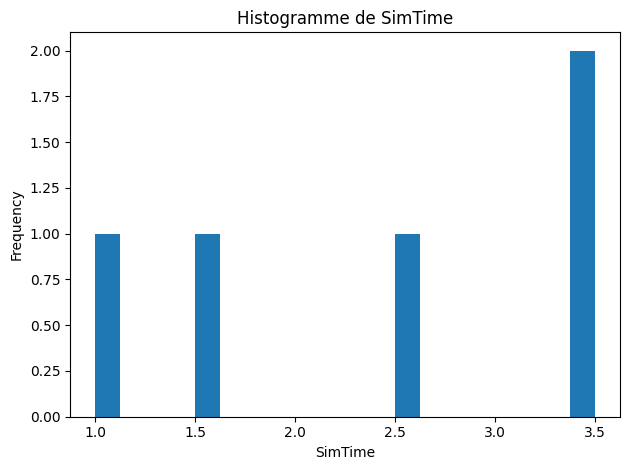


Graph sauvegardé dans: hist.png


In [10]:

run_llm_visualizer(
     file="data/lidata.log",
     prompt="Histogramme de SimTime",
     out="hist.png"
 )




INTENTION DETECTEE (safe):
 {'intent': 'scatter', 'chart': 'scatter', 'aggregation': 'mean', 'x': 'Spatial_FPB_WorldLocation_x', 'y': 'ForceIdentifier', 'group_by': None, 'top_n': None, 'bins': None, 'filter': []}

DEBUG INTENTION (safe/raw): {'intent': 'scatter', 'chart': 'scatter', 'aggregation': 'mean', 'x': 'Spatial_FPB_WorldLocation_x', 'y': 'ForceIdentifier', 'group_by': None, 'top_n': None, 'bins': None, 'filter': []}
[debug] CanonicalIntent: CanonicalIntent(kind='SCATTER_XY', filters=[], group_by=None, x='Spatial_FPB_WorldLocation_x', y='ForceIdentifier', aggregation=None, chart_hint='scatter', top_n=None, bins=None)
[debug] PlotSpec: PlotSpec(plot_type='scatter', x='Spatial_FPB_WorldLocation_x', y='ForceIdentifier', group_by=None, filters=[], sort_by=None, sort_ascending=False, aggregation=None, top_n=None, bins=None)


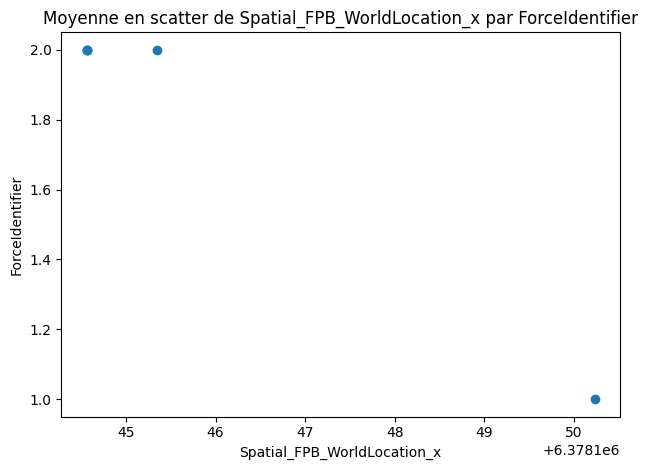


Graph sauvegardé dans: moyenne_test.png


In [ ]:
run_llm_visualizer(
     file="data/lidata.log",
     prompt="Moyenne en scatter de Spatial_FPB_WorldLocation_x par ForceIdentifier",
     out="moyenne_test.png"
)

[intent-repair] agg='nunique' sans y avec group_by -> count

INTENTION DETECTEE (safe):
 {'intent': 'nunique', 'chart': 'table', 'aggregation': 'count', 'group_by': 'EntityIdentifier', 'x': None, 'y': None, 'top_n': None, 'bins': None, 'filter': []}

DEBUG INTENTION (safe/raw): {'intent': 'nunique', 'chart': 'table', 'aggregation': 'count', 'group_by': 'EntityIdentifier', 'x': None, 'y': None, 'top_n': None, 'bins': None, 'filter': []}
[debug] CanonicalIntent: CanonicalIntent(kind='TABLE_BY_GROUP', filters=[], group_by='EntityIdentifier', x=None, y=None, aggregation='count', chart_hint='table', top_n=None, bins=None)
[debug] PlotSpec: PlotSpec(plot_type='table', x=None, y=None, group_by='EntityIdentifier', filters=[], sort_by='value', sort_ascending=False, aggregation='count', top_n=None, bins=None)


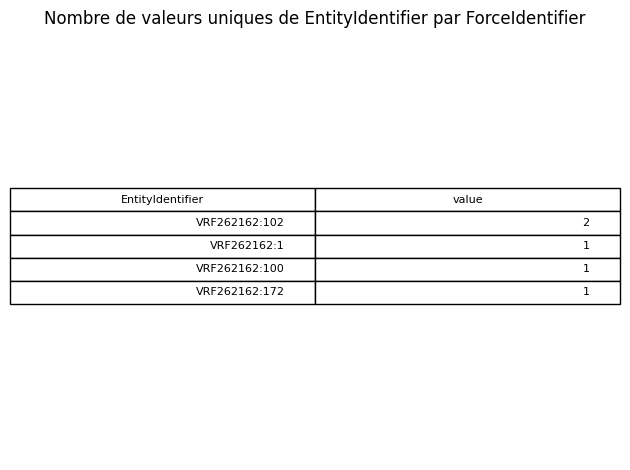


Graph sauvegardé dans: nunique_test.png


In [ ]:
run_llm_visualizer(
     file="data/lidata.log",
     prompt="Nombre de valeurs uniques de EntityIdentifier par ForceIdentifier",
     out="nunique_test.png"
)



[intent-repair] agg='nunique' sans y avec group_by -> count

INTENTION DETECTEE (safe):
 {'intent': 'table', 'chart': 'bar', 'aggregation': 'count', 'group_by': 'EntityIdentifier', 'x': None, 'y': None, 'top_n': None, 'bins': None, 'filter': []}

DEBUG INTENTION (safe/raw): {'intent': 'table', 'chart': 'bar', 'aggregation': 'count', 'group_by': 'EntityIdentifier', 'x': None, 'y': None, 'top_n': None, 'bins': None, 'filter': []}
[debug] CanonicalIntent: CanonicalIntent(kind='COUNT_BY_GROUP', filters=[], group_by='EntityIdentifier', x=None, y=None, aggregation='count', chart_hint='bar', top_n=None, bins=None)
[debug] PlotSpec: PlotSpec(plot_type='bar_agg', x=None, y=None, group_by='EntityIdentifier', filters=[], sort_by='value', sort_ascending=False, aggregation='count', top_n=None, bins=None)


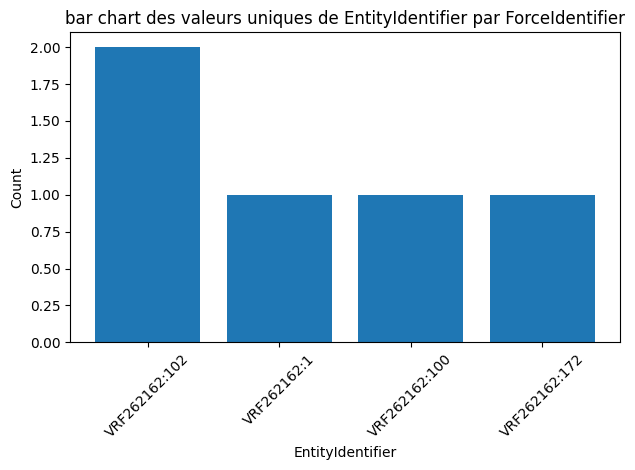


Graph sauvegardé dans: nuniqueBar_test.png


In [27]:
run_llm_visualizer(
     file="data/lidata.log",
     prompt="bar chart des valeurs uniques de EntityIdentifier par ForceIdentifier",
     out="nuniqueBar_test.png"
)

[intent-repair] agg='nunique' sans y avec group_by -> count

INTENTION DETECTEE (safe):
 {'intent': 'count', 'chart': 'pie', 'aggregation': 'count', 'group_by': 'EntityIdentifier', 'x': None, 'y': None, 'top_n': None, 'bins': None, 'filter': []}

DEBUG INTENTION (safe/raw): {'intent': 'count', 'chart': 'pie', 'aggregation': 'count', 'group_by': 'EntityIdentifier', 'x': None, 'y': None, 'top_n': None, 'bins': None, 'filter': []}
[debug] CanonicalIntent: CanonicalIntent(kind='COUNT_BY_GROUP', filters=[], group_by='EntityIdentifier', x=None, y=None, aggregation='count', chart_hint='pie', top_n=None, bins=None)
[debug] PlotSpec: PlotSpec(plot_type='pie', x=None, y=None, group_by='EntityIdentifier', filters=[], sort_by='value', sort_ascending=False, aggregation='count', top_n=None, bins=None)


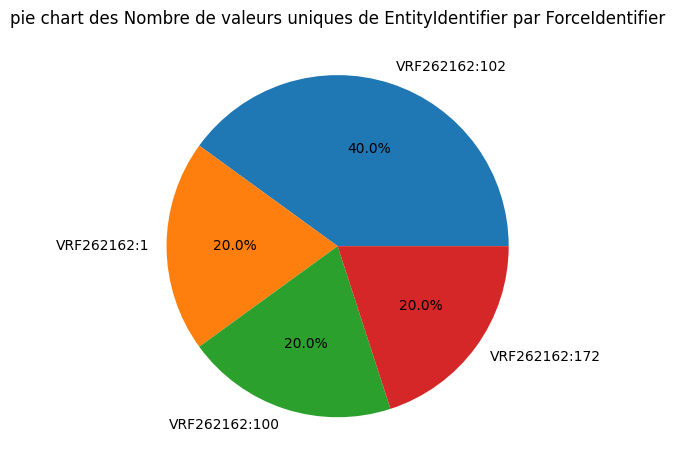


Graph sauvegardé dans: nuniquePie_test.png


In [18]:
run_llm_visualizer(
     file="data/lidata.log",
     prompt="pie chart des Nombre de valeurs uniques de EntityIdentifier par ForceIdentifier",
     out="nuniquePie_test.png"
)


INTENTION DETECTEE (safe):
 {'intent': 'metric', 'chart': 'auto', 'aggregation': 'nunique', 'group_by': None, 'x': None, 'y': 'EntityIdentifier', 'top_n': None, 'bins': None, 'filter': []}

DEBUG INTENTION (safe/raw): {'intent': 'metric', 'chart': 'auto', 'aggregation': 'nunique', 'group_by': None, 'x': None, 'y': 'EntityIdentifier', 'top_n': None, 'bins': None, 'filter': []}
[debug] CanonicalIntent: CanonicalIntent(kind='METRIC_AGG', filters=[], group_by=None, x=None, y='EntityIdentifier', aggregation='nunique', chart_hint='metric', top_n=None, bins=None)
[debug] PlotSpec: PlotSpec(plot_type='metric', x=None, y='EntityIdentifier', group_by=None, filters=[], sort_by=None, sort_ascending=False, aggregation='nunique', top_n=None, bins=None)


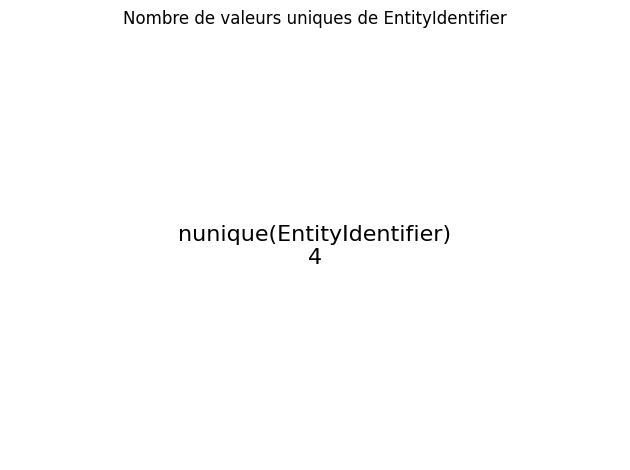


Graph sauvegardé dans: nuniqueNormal.png


In [19]:
run_llm_visualizer(
     file="data/lidata.log",
     prompt="Nombre de valeurs uniques de EntityIdentifier",
     out="nuniqueNormal.png"
)


INTENTION DETECTEE (safe):
 {'intent': 'count', 'chart': 'table', 'aggregation': 'count', 'x': None, 'y': 'EntityIdentifier', 'top_n': None, 'bins': None, 'filter': [], 'group_by': None}

DEBUG INTENTION (safe/raw): {'intent': 'count', 'chart': 'table', 'aggregation': 'count', 'x': None, 'y': 'EntityIdentifier', 'top_n': None, 'bins': None, 'filter': [], 'group_by': None}
[debug] CanonicalIntent: CanonicalIntent(kind='COUNT_ROWS', filters=[], group_by=None, x=None, y=None, aggregation='count', chart_hint='metric', top_n=None, bins=None)
[debug] PlotSpec: PlotSpec(plot_type='metric', x=None, y=None, group_by=None, filters=[], sort_by=None, sort_ascending=False, aggregation='count', top_n=None, bins=None)


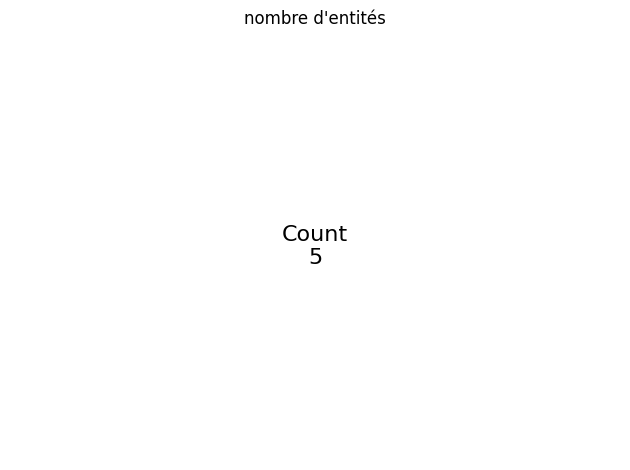


Graph sauvegardé dans: Metric_test.png


In [21]:
run_llm_visualizer(
     file="data/lidata.log",
     prompt="nombre d'entités",
     out="Metric_test.png"
)


INTENTION DETECTEE (safe):
 {'intent': 'metric', 'chart': 'histogram', 'aggregation': None, 'group_by': None, 'x': 'Spatial_FPB_WorldLocation_x', 'y': None, 'top_n': None, 'bins': None, 'filter': []}

DEBUG INTENTION (safe/raw): {'intent': 'metric', 'chart': 'histogram', 'aggregation': None, 'group_by': None, 'x': 'Spatial_FPB_WorldLocation_x', 'y': None, 'top_n': None, 'bins': None, 'filter': []}
[debug] CanonicalIntent: CanonicalIntent(kind='HISTOGRAM_X', filters=[], group_by=None, x='Spatial_FPB_WorldLocation_x', y=None, aggregation=None, chart_hint='histogram', top_n=None, bins=20)
[debug] PlotSpec: PlotSpec(plot_type='histogram', x='Spatial_FPB_WorldLocation_x', y=None, group_by=None, filters=[], sort_by='x', sort_ascending=True, aggregation=None, top_n=None, bins=20)


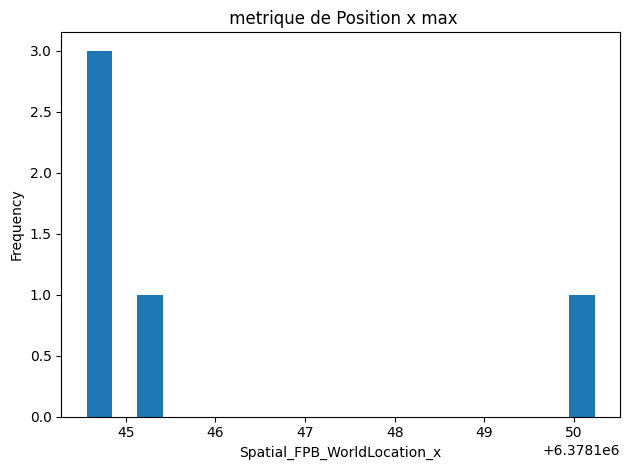


Graph sauvegardé dans: xmax.png


In [23]:
run_llm_visualizer(
     file="data/lidata.log",
     prompt=" metrique de Position x max",
     out="xmax.png"
)

[intent-repair] agg='nunique' sans y avec group_by -> count
[intent-repair] répartition legacy -> chart='bar'

INTENTION DETECTEE (safe):
 {'intent': 'distribution', 'chart': 'bar', 'aggregation': 'count', 'group_by': 'ForceIdentifier', 'x': None, 'y': None, 'top_n': None, 'bins': None, 'filter': []}

DEBUG INTENTION (safe/raw): {'intent': 'distribution', 'chart': 'bar', 'aggregation': 'count', 'group_by': 'ForceIdentifier', 'x': None, 'y': None, 'top_n': None, 'bins': None, 'filter': []}
[debug] CanonicalIntent: CanonicalIntent(kind='COUNT_BY_GROUP', filters=[], group_by='ForceIdentifier', x=None, y=None, aggregation='count', chart_hint='bar', top_n=None, bins=None)
[debug] PlotSpec: PlotSpec(plot_type='bar_agg', x=None, y=None, group_by='ForceIdentifier', filters=[], sort_by='value', sort_ascending=False, aggregation='count', top_n=None, bins=None)


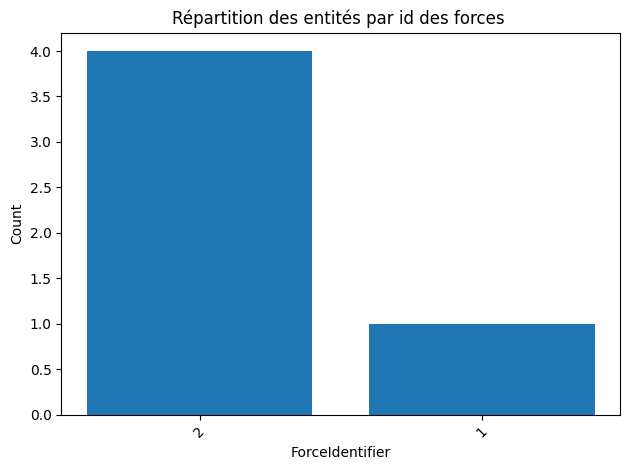


Graph sauvegardé dans: out68.png


In [25]:
run_llm_visualizer(
    file="data/lidata.log",
    prompt="Répartition des entités par id des forces ",
    out="out68.png"
    
)

[intent-repair] agg='nunique' sans y avec group_by -> count
[intent-repair] répartition legacy -> chart='bar'

INTENTION DETECTEE (safe):
 {'intent': 'distribution', 'chart': 'bar', 'aggregation': 'count', 'group_by': 'ForceIdentifier', 'x': None, 'y': None, 'top_n': None, 'bins': None, 'filter': []}

DEBUG INTENTION (safe/raw): {'intent': 'distribution', 'chart': 'bar', 'aggregation': 'count', 'group_by': 'ForceIdentifier', 'x': None, 'y': None, 'top_n': None, 'bins': None, 'filter': []}
[debug] CanonicalIntent: CanonicalIntent(kind='COUNT_BY_GROUP', filters=[], group_by='ForceIdentifier', x=None, y=None, aggregation='count', chart_hint='bar', top_n=None, bins=None)
[debug] PlotSpec: PlotSpec(plot_type='bar_agg', x=None, y=None, group_by='ForceIdentifier', filters=[], sort_by='value', sort_ascending=False, aggregation='count', top_n=None, bins=None)


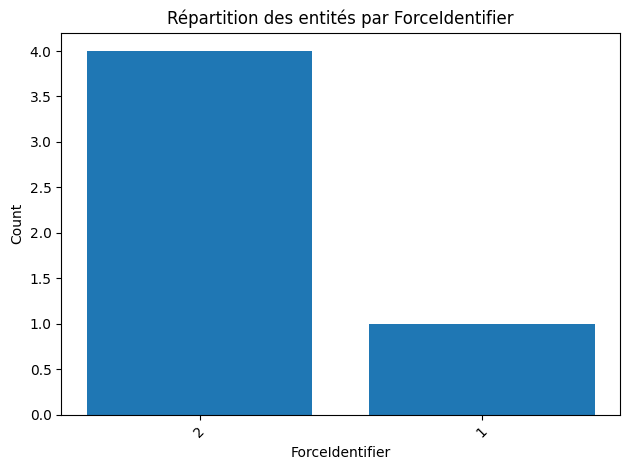


Graph sauvegardé dans: out8.png


In [24]:
run_llm_visualizer(
    file="data/lidata.log",
    prompt="Répartition des entités par ForceIdentifier",
    out="out8.png"
)



INTENTION DETECTEE (safe):
 {'intent': 'scatter', 'chart': 'scatter', 'x': 'Spatial_FPB_WorldLocation_x', 'y': 'Spatial_FPB_WorldLocation_y', 'aggregation': None, 'group_by': None, 'top_n': None, 'bins': None, 'filter': []}

DEBUG INTENTION (safe/raw): {'intent': 'scatter', 'chart': 'scatter', 'x': 'Spatial_FPB_WorldLocation_x', 'y': 'Spatial_FPB_WorldLocation_y', 'aggregation': None, 'group_by': None, 'top_n': None, 'bins': None, 'filter': []}
[debug] CanonicalIntent: CanonicalIntent(kind='SCATTER_XY', filters=[], group_by=None, x='Spatial_FPB_WorldLocation_x', y='Spatial_FPB_WorldLocation_y', aggregation=None, chart_hint='scatter', top_n=None, bins=None)
[debug] PlotSpec: PlotSpec(plot_type='scatter', x='Spatial_FPB_WorldLocation_x', y='Spatial_FPB_WorldLocation_y', group_by=None, filters=[], sort_by=None, sort_ascending=False, aggregation=None, top_n=None, bins=None)


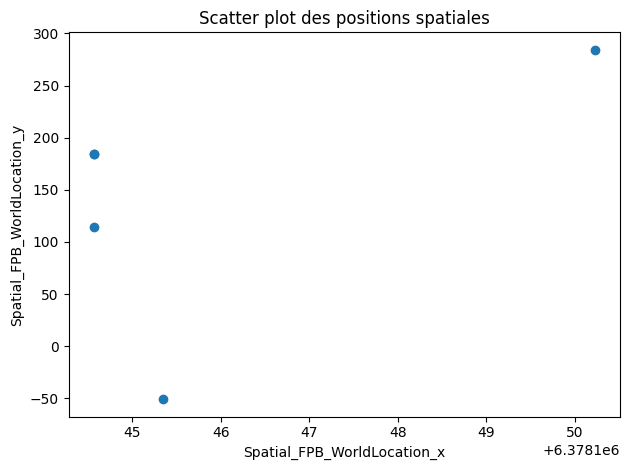


Graph sauvegardé dans: out77.png


In [26]:
run_llm_visualizer(
    file="data/lidata.log",
    prompt="Scatter plot des positions spatiales",
    out="out77.png"
)




INTENTION DETECTEE (safe):
 {'intent': 'time_series', 'chart': 'line', 'aggregation': None, 'group_by': None, 'x': 'SimTime', 'y': 'Spatial_FPB_WorldLocation_x', 'top_n': None, 'bins': None, 'filter': []}

DEBUG INTENTION (safe/raw): {'intent': 'time_series', 'chart': 'line', 'aggregation': None, 'group_by': None, 'x': 'SimTime', 'y': 'Spatial_FPB_WorldLocation_x', 'top_n': None, 'bins': None, 'filter': []}
[debug] CanonicalIntent: CanonicalIntent(kind='LINE_XY', filters=[], group_by=None, x='SimTime', y='Spatial_FPB_WorldLocation_x', aggregation=None, chart_hint='line', top_n=None, bins=None)
[debug] PlotSpec: PlotSpec(plot_type='line', x='SimTime', y='Spatial_FPB_WorldLocation_x', group_by=None, filters=[], sort_by='x', sort_ascending=True, aggregation=None, top_n=None, bins=None)


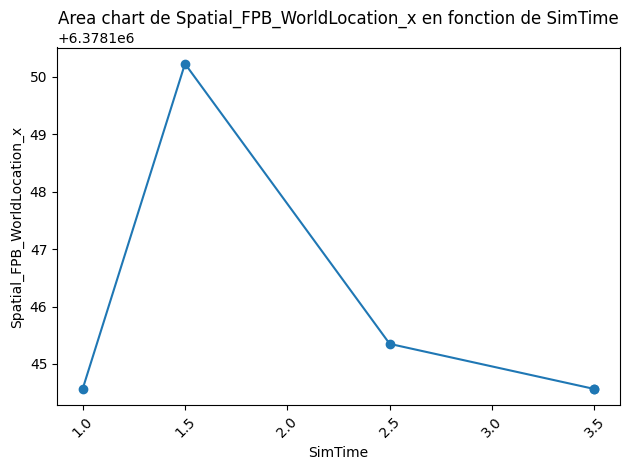


Graph sauvegardé dans: area_test.png


In [7]:
run_llm_visualizer(
    file="data/lidata.log",
    prompt="Area chart de Spatial_FPB_WorldLocation_x en fonction de SimTime",
    out="area_test.png"
)
